In [2]:
!pip install numpy pandas scipy matplotlib statsmodels scikit-learn plotly pingouin openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import poisson, chi2_contingency, mannwhitneyu, f_oneway, chisquare
from scipy import stats
from scipy.stats import wilcoxon
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

'''# Statistical modeling
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


# Machine learning utilities
from sklearn.preprocessing import StandardScaler'''

# Excel file handling
import openpyxl

In [4]:
# Loading an excel file
finance_df = pd.read_excel(r'C:\Users\HP\Desktop\Data Science Folder\Python Projects\Statistics Assignment\finaccess2024_datasprint.xlsx')

In [5]:
finance_df.head()

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


In [6]:
# checking for data types in each column
finance_df.dtypes

county                      str
location_type               str
Sex                         str
Age                         str
household_size            int64
education_level          object
marital_status              str
monthly_income            int64
Savings_formal              str
Savings_informal            str
Loan_formal                 str
Loan_informal               str
defaulted                   str
formal_service_use          str
mobile_money_access         str
barriers_mobile_money    object
mobile_ownership_1          str
experienced_shock           str
nfhi_11                     str
nfhi_12                     str
nfhi_13                     str
accessto_13k_1month         str
not_difficult               str
financial_status            str
fl_score                    str
prodsum1                  int64
barriers_bank               str
has_disability              str
dtype: object

In [7]:
finance_df['monthly_income'].describe()

count     20871.000000
mean       9702.774280
std       15423.366592
min         100.000000
25%        2500.000000
50%        5000.000000
75%       10000.000000
max      200000.000000
Name: monthly_income, dtype: float64

# SECTION 1

### Q1.  Describe the typical monthly income of a household in this dataset. Which measure of central tendency would you use, and why might a different measure give a misleading picture? 
- The typical monthly income is 5000, and the measure of central tendency is median. The mean will give a misleading picture since it has outliers that might lead to a skewed distribution of the dataset. The mode will not provide an accurate measure of central tendency when the most common mark is far away from the rest of the data in the data set.

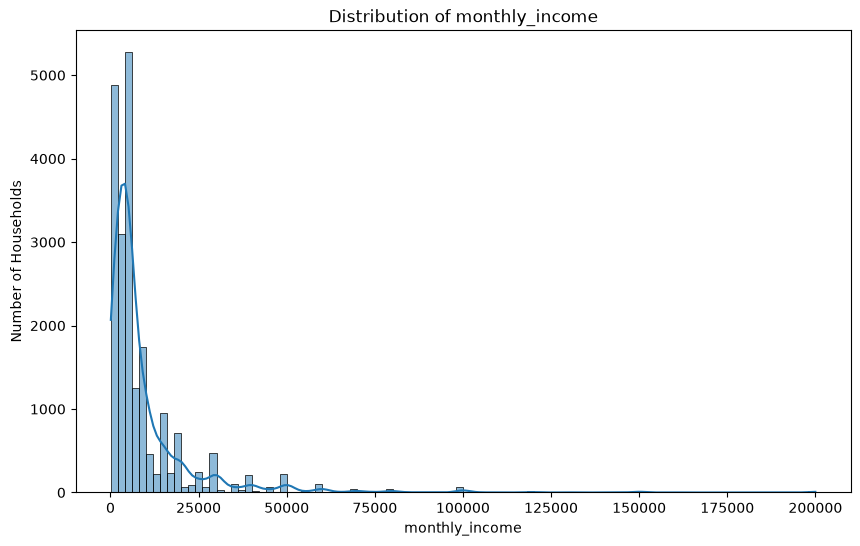

In [8]:
# Look at the shape of the income distribution before choosing your measure.
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", bins=100, kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Number of Households")
plt.show()

##### It indicates that the few exeptionally high values are on the right side. Therefore it's positive/right skewed distribution.

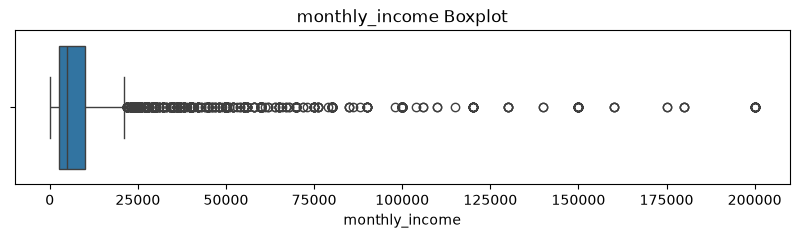

In [9]:
plt.figure(figsize=(10,2))
sns.boxplot(x=finance_df["monthly_income"])

plt.title("monthly_income Boxplot")
plt.show()

In [10]:
Q1 = 2500
Q3 = 10000
IQR = 7500
lower_limit = Q1 - (1.5 * IQR) 
upper_limit = Q3 + (1.5 * IQR) 
print(lower_limit , upper_limit)

-8750.0 21250.0


In [11]:
median = finance_df['monthly_income'].median()
print(median)

5000.0


In [12]:
mean = finance_df['monthly_income'].mean()
print(mean)

9702.774280101576


#### When is the mean a poor representative of 'typical'? 
- The mean is susceptible(easily influenced) to outliers, therefore when the dataset has outliers, the mean becomes skwewed, therefore it does not give an accurate measure of central tendency.

#### Compare what the mean and median tell you — are they close or far apart?
- The mean is 9702.77 and the median is 5000.0 because of the outliers that pull the mean to the right.
- The mean of a right-skewed distribution is almost always greater than its median. That’s because extreme values (the values in the tail) affect the mean more than the median. (Right skew: mean > median)

#### Think about what 'typical' means for a policy maker designing a financial product.
- The typical monthly income for the household in the dataset is 5000, the policy makers designing financial products should be informed to design financial products that align to the typical monthly income. Financial products like health insurance, emergency loans, mobile loans e.t.c that are more affordable and accessible to a majority of the target population.

### Q2.  What does the most common household size tell us about Kenyan households? How would you identify and report this, and what are its limitations as a summary? 
The most common household size is 1. It indicates that single-person households are the most common type of household in the surveyed Kenyan population. To Identify the most common houshold size, I would use the mode. A limitation of using the mode, is that it only shows the most frequent which may not be necessarily be the center of the data. Another limitation is that there may be more than one mode (bimodal or multimodal data). The median and the mean best reflect the central tendency of the overall distribution.

In [13]:
mode = finance_df['household_size'].mode()
print(mode)

0    1
Name: household_size, dtype: int64


### Which measure of central tendency captures the most frequently occurring value? 
 - The most common household size is 1. 
 - The measure of central tendency used was the mode. This is because the mode is the value that appears most frequently in a dataset. Since we need the household size that occurs more frequently,it is more suitable. The mean and the median are not suitable in this case beacause they both best represent the typical (average) household size.

- The mode can be used for both categorical and numerical variable

- If two values tie for the most common, you report the tied values as bimodal(two ties).

- The single value does not describe the spread of household sizes in the data

In [14]:
mean = finance_df['household_size'].mean()
print(mean)

4.215945570408701


In [15]:
median = finance_df['household_size'].median()
print(median)

4.0


In [16]:
finance_df.head()

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


##### What type of variable is financial literacy score — is it numeric or categorical? 
- The financial literacy score is a categorical variable

##### Is there a meaningful numeric distance between 'None correct' and 'One correct'? 
- YES

In [17]:
finance_df["fl_score"].value_counts()

fl_score
Two correct     8580
All correct     8085
One correct     3493
None correct     713
Name: count, dtype: int64

In [18]:
numeric_distance = finance_df[finance_df["fl_score"].isin(["One correct", "None correct"])]['fl_score'].value_counts()
print(numeric_distance)

fl_score
One correct     3493
None correct     713
Name: count, dtype: int64


In [19]:
none_correct_count = len(finance_df[finance_df["fl_score"] == "None correct"])
one_correct_count = len(finance_df[finance_df["fl_score"] == "One correct"])

numeric_distance = one_correct_count - none_correct_count

print(f"Financial Literacy - One Correct: {one_correct_count}")
print(f"Financial Literacy - None Correct: {none_correct_count}")
print(f"Numeric Distance: {numeric_distance}")

Financial Literacy - One Correct: 3493
Financial Literacy - None Correct: 713
Numeric Distance: 2780


In [20]:
mode = finance_df['fl_score'].mode()
print(mode)

0    Two correct
Name: fl_score, dtype: str


#### What alternative summary would be more appropriate here? 
The alternative summary that would be appropriate is the mode. The mean is not appropriate in this case since our column is a categorical variable.

               count          mean  median  min     max
location_type                                          
Rural          13549   7691.277142  5000.0  100  200000
Urban           7322  13424.950560  7000.0  100  200000


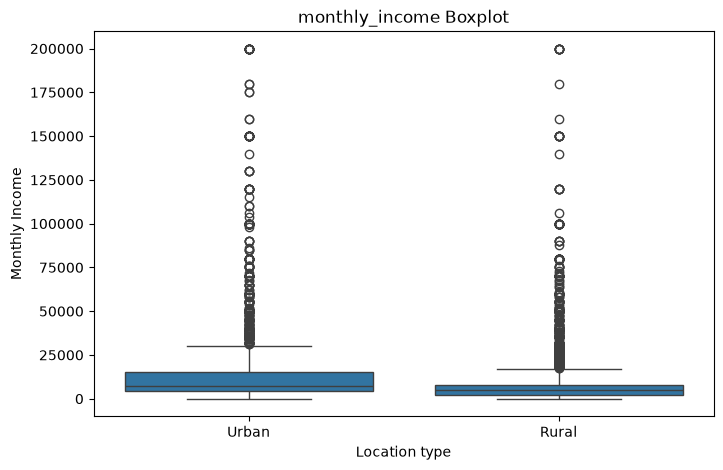

In [21]:
income_stats = finance_df.groupby("location_type")["monthly_income"].agg(["count", "mean", "median", "min", "max"])
print(income_stats)

plt.figure(figsize=(8,5))
sns.boxplot(x=finance_df["location_type"], y=finance_df["monthly_income"])

plt.title("monthly_income Boxplot")
plt.xlabel("Location type")
plt.ylabel("Monthly Income")
plt.show()

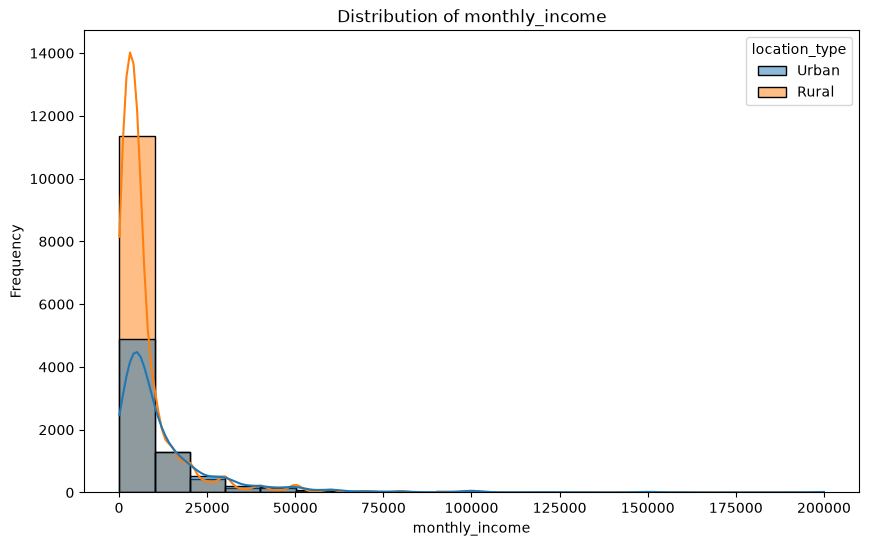

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", hue="location_type", bins=20, kde=True) #hue tells Seaborn to split the data into groups based on a categorical variable and display each group in a different color.

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Frequency")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 2000x600 with 0 Axes>

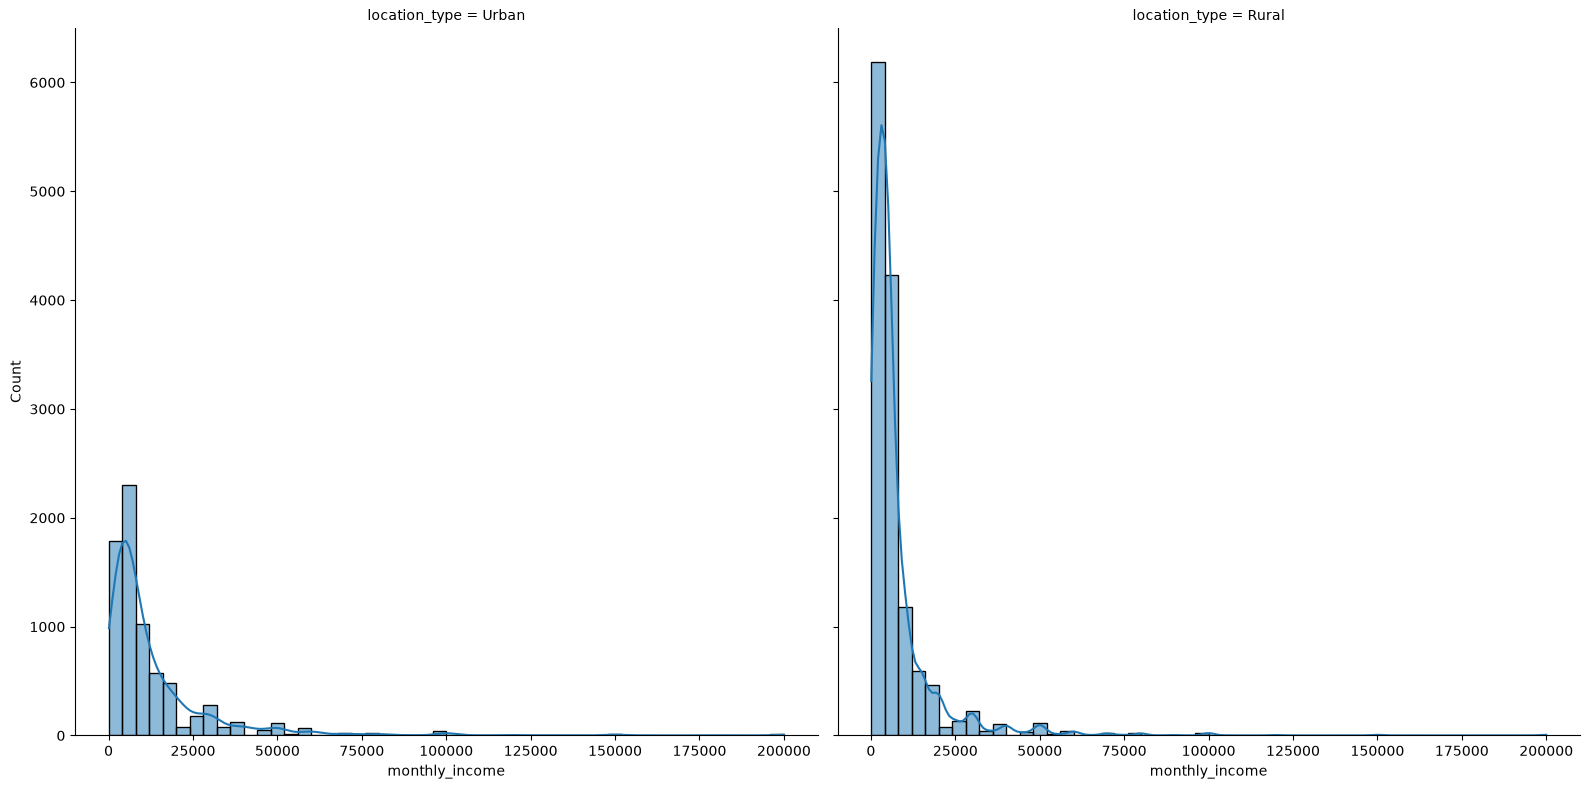

In [23]:
plt.figure(figsize=(20,6))
g = sns.FacetGrid(finance_df, col="location_type", height=8) #FacetGrid means: "Create separate plots for each category in a variable.
                                                             # col="location_type" It tells Seaborn: "Make one column (plot) for every value in location_type.
                                                             # g  is just a variable, we can give it any name
                                                             # height is the length of the graph
g.map_dataframe(sns.histplot,x="monthly_income",bins=50,kde=True)
plt.xlabel("monthly_income")
plt.ylabel("Frequency")
plt.show

##### Should you use the same measure of central tendency for both groups? 
- Yes, the same measure of central tendency should be used for both groups i.e the median because the income distribution is positively skewed. A right-skewed dataset contains a long tail of extremely high values, these outliers will inflate the mean, making the median a far more accurate representation of the typical data point.

#### Think about what a large gap between groups would imply for access to financial services.
A large gap between groups would indicate a difference in access to financial services. Urban respondents have a greater income variability which makes the typical income higher as compared to rural respondents. They are therefore more likely to access financial services easily due to their substatially higher income.

#### Are there other variables (e.g. education, location) that might explain the difference?
1. Education level  
Education is a strong predictor of income, higher education level is mostly associated with urban areas as compared to rural areas.

2. Age  
In urban areas, income steadily increases with age due to formal career advancement and skill accumulation while in rural areas income peaks earlier in life and often declines in later years.

# SECTION 2: Measures of Dispersion 

#### Is the range alone a reliable measure here? What can distort it?
Range is not a relaibale measure because range only gets the difference between the largest and the smallest value and therefore it is not suitable for a dataset that has outliers.

#### What does the IQR capture that the range does not?
The IQR gives an accurate picture of the data because it shows where the bulk of the data truly lies since it is resistant to outliers. While the range makes the data spread look much larger than it actually is since it is vulnerable to outliers.

In [24]:
Q1 = 2500
Q3 = 10000
IQR = 7500
lower_limit = Q1 - (1.5 * IQR) 
upper_limit = Q3 + (1.5 * IQR)
print(lower_limit , upper_limit)

-8750.0 21250.0


In [25]:
IQR = finance_df["monthly_income"].quantile(0.75) - finance_df["monthly_income"].quantile(0.25)
print(IQR)

7500.0


The middle 50% of households earn between KES 2500 and 10000. This indicates that the incomes of typical households vary by KES 7500. Because income is often skewed by a few very high earners, the IQR provides a better picture of the income range experienced by most households.

#### How would you communicate this variability to a non-technical audience? 
What the IQR simply does is that it arranges the monthly income of each household from the lowest to the highest and therefore we find out that the first 25% of the households earn less than 2,500, while the 2nd quartile which is 50% earn between 5,000 and 7,500 and lastly the third quartile which is the 75% earn more than 7,500. This simply means that the middle 50% of the households which is half of the households earn a monthly income between 5,000 to 7,500. The reason as to why the IQR does not cover every household is because some households earn extremely high income which may pull the mean upwards and this makes the households look like they earn more than they do. Therefore, the IQR avoids this by focusing on the center which is the 50% while ignoring the extremely high incomes.

In [26]:
finance_df['monthly_income'].describe()

count     20871.000000
mean       9702.774280
std       15423.366592
min         100.000000
25%        2500.000000
50%        5000.000000
75%       10000.000000
max      200000.000000
Name: monthly_income, dtype: float64

## Q6. Two communities report the same average monthly income but very different standard deviations. What does this tell us, and how would it affect financial product design for each community?
- Community with a high std deviation are less likely to accces financial products beacause their income is unpredictable as compared to community with a low std deviation which is more likely to access financial products since their income id predictable.

- The level of variation in a population is important when designing financial products. When there is little variation (low standard deviation), meaning most people have similar financial characteristics, a standard financial product is more likely to meet the needs of most customers. For example, if most households have similar incomes and spending patterns, a financial institution can offer a standard savings account or a health insurance plan with the same premium and level of coverage for most customers. However, when there is a lot of variation (high standard deviation), people have different financial needs and abilities, so one product may not work well for everyone. For instance, households with lower incomes may need affordable insurance plans with lower premiums, while higher-income households may prefer more comprehensive health or education insurance plans with higher premiums and greater benefits. In such cases, financial institutions should offer a range of products or flexible options to better meet the needs of different groups of customers.

#### What does a high standard deviation indicate about the data points relative to the mean?
A high standard deviation indicates that the data points are highly dispersed, meaning they are spread out over a wider range and deviate significantly from the mean. Conversely, a low standard deviation indicates that the data points are clustered tightly around the mean.

#### Think about which community has more predictable income — and why that matters for loan repayment. 
- Community that has a predictable income, are likely to repay their loans because of the low standard deviation which indicates that their data points are clustered near the mean. As compared to a community that their income is unpredictable since their data points are scattered away from the the mean hence they are unlikely to repay their loans.

- A community with a predictable income is more likely to repay its loans on time because most households earn amounts that are close to the average income. This is shown by a low standard deviation, which means incomes do not vary much from one household to another. In contrast, a community with less predictable income may find it harder to repay loans consistently because household incomes differ widely. This is shown by a high standard deviation, which means some households earn much more than the average while others earn much less. As a result, some households may struggle to make their loan repayments.

#### Is standard deviation always appropriate? What assumption does it carry about the distribution? 
- No, it is not appropriate to use beacuse it doesn't work best with data that has outliers. 
- Standard deviation assumes normal distribution, therefore if data is skewed or has outliers standard deviation might not show the real amount of variation or risk in the dataset.

#### How might you visualise this difference?
- The most appropriate visualisation for the difference would be a density plot, this is because it enables comparisons between multiple groups.
- The choice of chart always depends on the Std deviation, for a low std deviation, a histogram would be approriate since it shows tight clustering while for a high std deviation, a scatter plot or violoin plot would be ideal since it highlights spread of data points. In this case, a density plot is the most appropriate since it shows the comparison between the two communities.

#### Start with basic descriptive statistics: min, max, mean, median, IQR. 

In [27]:
finance_df['prodsum1'].describe()

count    20871.000000
mean         3.936563
std          3.227992
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         22.000000
Name: prodsum1, dtype: float64

In [28]:
mean = finance_df['prodsum1'].mean()
median = finance_df['prodsum1'].median()
max = finance_df['prodsum1'].max()
min = finance_df['prodsum1'].min()
Q1 = finance_df['prodsum1'].quantile(0.25)
Q3 = finance_df['prodsum1'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - (1.5 * IQR) 
upper_limit = Q3 + (1.5 * IQR) 

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Max: {max}")
print(f"Min: {min}")
print(f"Quantile 1: {Q1}")
print(f"Quantile 3: {Q3}")
print(f"Inter Quantile Range: {IQR}")
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

Mean: 3.9365626946480763
Median: 3.0
Max: 22
Min: 0
Quantile 1: 1.0
Quantile 3: 6.0
Inter Quantile Range: 5.0
Lower limit: -6.5
Upper limit: 13.5


### Explore the variability in the number of financial products used across households. Are there households that appear unusually active or unusually inactive in financial services?
There are households with unusually active in access financial products, but there is no household that is unusually inactive in access to financial products. Although some households appear to own substantially more financial products than others, the observed differences are more strongly associated with income, education, age, and urban residence than with household size. No single factor fully explains product uptake, suggesting that financial service access is influenced by a combination of demographic and socioeconomic characteristics.

### What visual tool would help you see the full spread, including extreme values? 
The best visual to use is a histogram and a boxplot to show the distribution and extreme outliers.

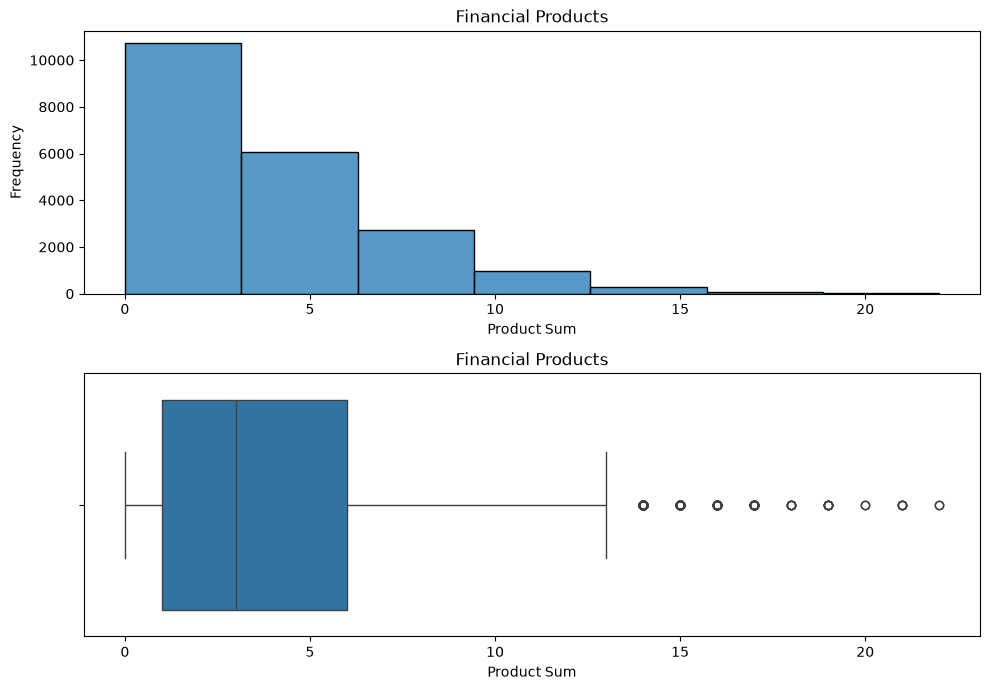

In [29]:
# Create the figure
plt.figure(figsize=(10, 10))

# Histogram (top)
plt.subplot(3, 1, 1)
sns.histplot(finance_df["prodsum1"], bins=7)
plt.title("Financial Products")
plt.xlabel("Product Sum")
plt.ylabel("Frequency")

# Box Plot (bottom)
plt.subplot(3, 1, 2)
sns.boxplot(x=finance_df["prodsum1"])
plt.title("Financial Products")
plt.xlabel("Product Sum")

'''# Density plot
plt.subplot(3, 1, 3)
sns.kdeplot(finance_df['prodsum1'])
plt.title("Financial Products")
plt.xlabel("Product Sum")
plt.ylabel("Frequency")'''

# Adjust spacing
plt.tight_layout()

# Display the plots
plt.show()

### How would you define 'unusually high' or 'unusually low' product usage statistically?
Outliers.

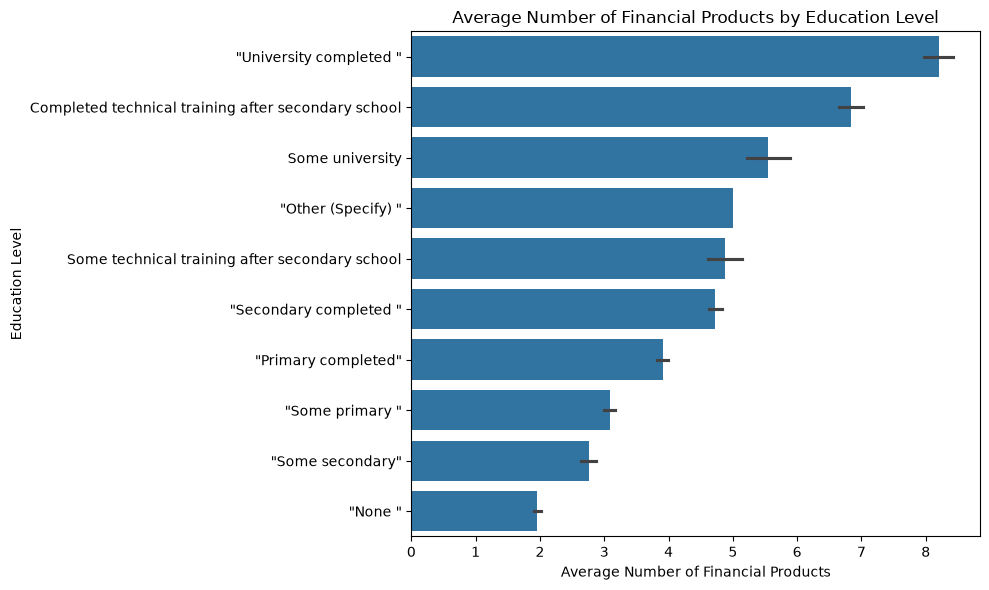

In [30]:
finance_df["education_level"] = finance_df["education_level"].astype(str).str.strip()

filtered_data = finance_df[
    ~finance_df["education_level"].str.contains(
        "Don't know|Refused|^95$",
        regex=True,
        na=False
    )
]

plt.figure(figsize=(10, 6))
order = ( filtered_data.groupby("education_level")["prodsum1"].mean().sort_values(ascending=False).index)
sns.barplot(x="prodsum1",y="education_level",data=filtered_data,order=order)
plt.xlabel("Average Number of Financial Products")
plt.ylabel("Education Level")
plt.title("Average Number of Financial Products by Education Level")

plt.tight_layout()
plt.show()

In [31]:
finance_df["education_level"].value_counts()

education_level
"Secondary completed "                                 4113
"Primary completed"                                    3953
"Some primary "                                        3731
"None "                                                3078
"Some secondary"                                       2731
Completed technical training after secondary school    1421
"University completed "                                 988
Some technical training after secondary school          501
Some university                                         346
"Refused to Answer (DO NOT READ OUT)"                     3
"Other (Specify) "                                        2
95                                                        2
"Don't know (DO NOT READ OUT)"                            2
Name: count, dtype: int64

In [32]:
finance_df["location_type"].value_counts()

location_type
Rural    13549
Urban     7322
Name: count, dtype: int64

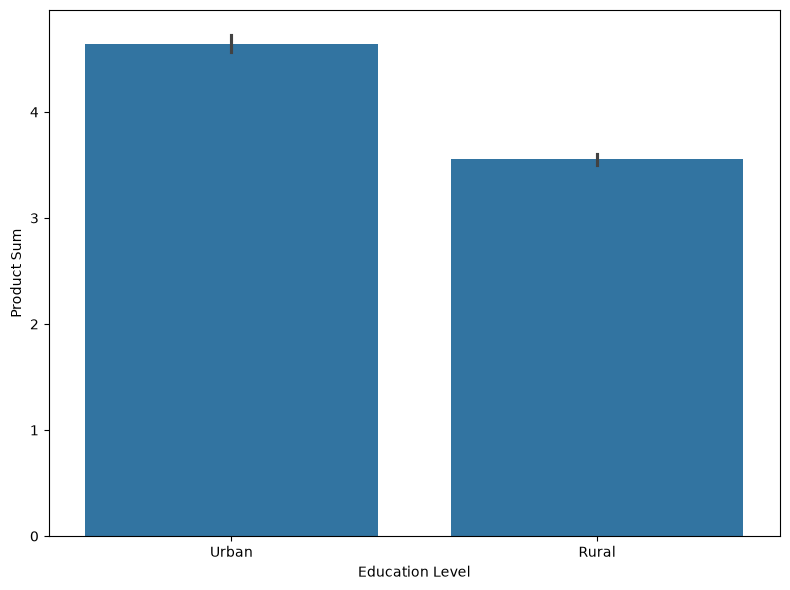

In [33]:
plt.figure(figsize=(8, 6))
order = (finance_df.groupby("location_type")["prodsum1"].mean().sort_values(ascending=False).index)
sns.barplot(x="location_type", y="prodsum1", data=finance_df, order=order)
plt.xlabel("Education Level")
plt.ylabel("Product Sum")

plt.tight_layout()
plt.show()

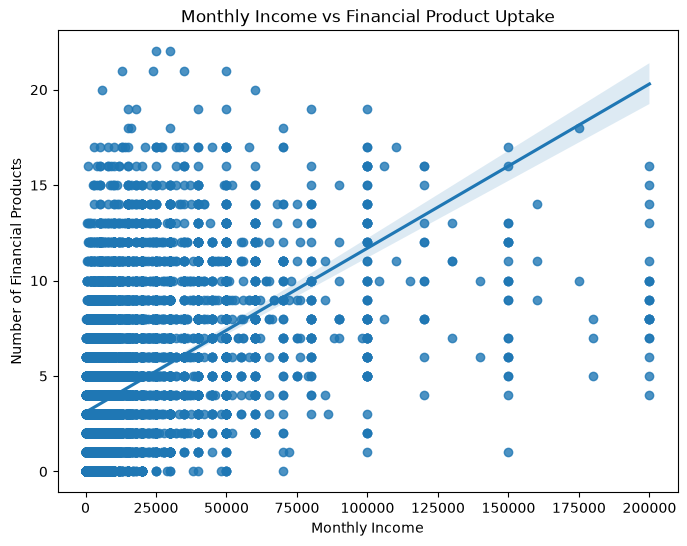

                monthly_income  prodsum1
monthly_income        1.000000  0.410813
prodsum1              0.410813  1.000000
                monthly_income  prodsum1
monthly_income        1.000000  0.168768
prodsum1              0.168768  1.000000


In [34]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=finance_df,
    x="monthly_income",
    y="prodsum1"
)

plt.title("Monthly Income vs Financial Product Uptake")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Financial Products")
plt.show()

r = finance_df[["monthly_income","prodsum1"]].corr()
print(r)
r_square = r ** 2
print(r_square)

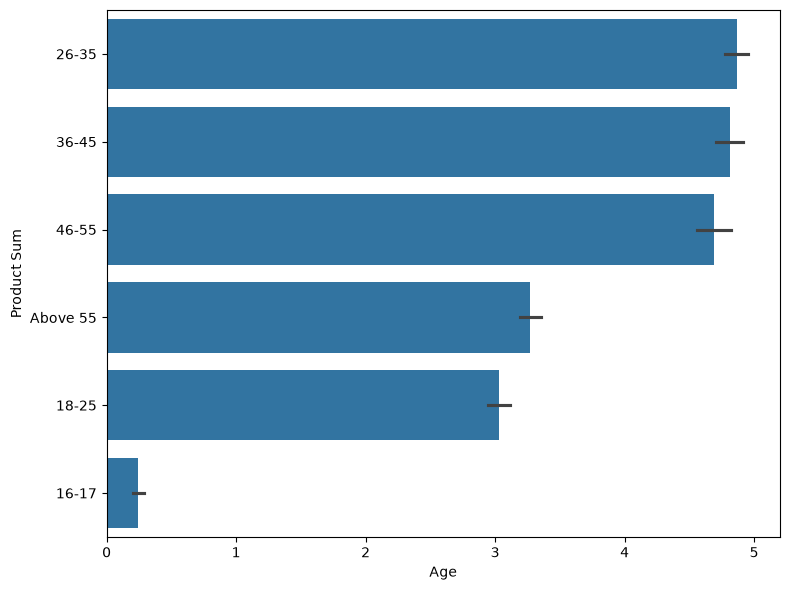

In [35]:
plt.figure(figsize=(8, 6))
order = (finance_df.groupby("Age")["prodsum1"].mean().sort_values(ascending=False).index)
sns.barplot(x="prodsum1",y="Age",data=finance_df, order=order)
plt.xlabel("Age")
plt.ylabel("Product Sum")

plt.tight_layout()
plt.show()

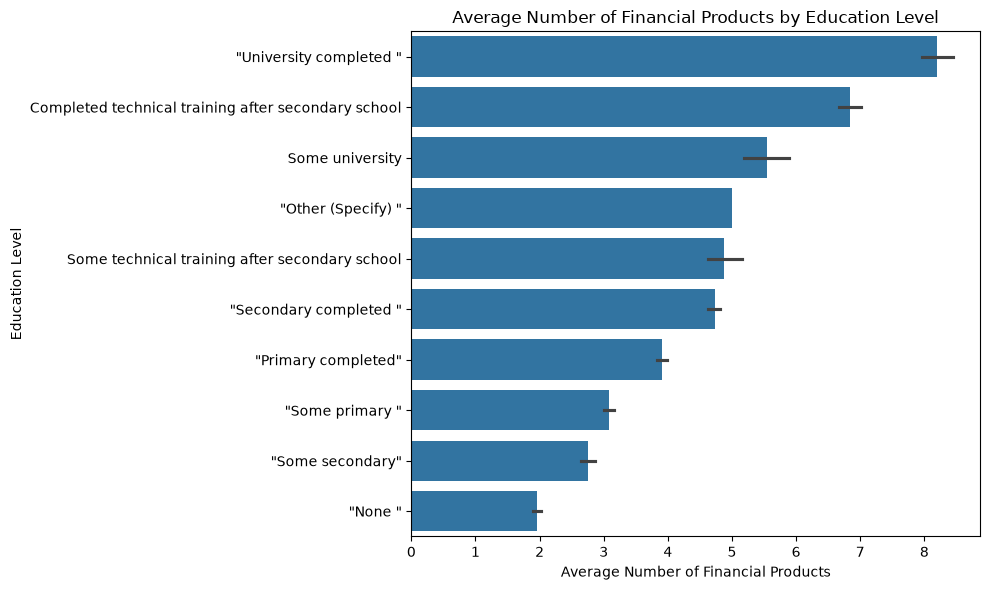

In [36]:
plt.figure(figsize=(10, 6))
order = ( filtered_data.groupby("education_level")["prodsum1"].mean().sort_values(ascending=False).index)
sns.barplot(x="prodsum1",y="education_level",data=filtered_data,order=order)
plt.xlabel("Average Number of Financial Products")
plt.ylabel("Education Level")
plt.title("Average Number of Financial Products by Education Level")

plt.tight_layout()
plt.show()

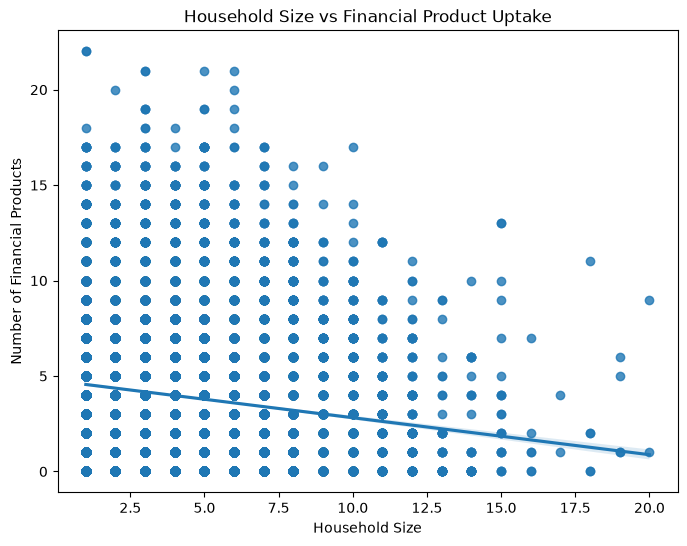

In [37]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=finance_df,
    x="household_size",
    y="prodsum1"
)


plt.title("Household Size vs Financial Product Uptake")
plt.xlabel("Household Size")
plt.ylabel("Number of Financial Products")
plt.show()

In [38]:
r = finance_df[["household_size","prodsum1"]].corr()
print(r)
r_square = r ** 2
print(r_square)

                household_size  prodsum1
household_size        1.000000 -0.150739
prodsum1             -0.150739  1.000000
                household_size  prodsum1
household_size        1.000000  0.022722
prodsum1              0.022722  1.000000


## SECTION 3 OUTLIERS
### Investigate whether the monthly income variable contains outliers. How would you detect them, and what would you do before deciding to remove any data points?
The monthly income variable has outliers and they're detected using the IQR rule. Before removing the outliers, check if they are errors, and if they are errors remove otherwise retain them. In addition outliers can corrected the errors if you have enough information to correct them. Lastly, whatever you decide amongst the three option, always give enough information to support your decision.


#### How does your decision affect the integrity of the analysis?
retaing them will give the actual representation of the data and therefore maintain the integrity of the analysis.

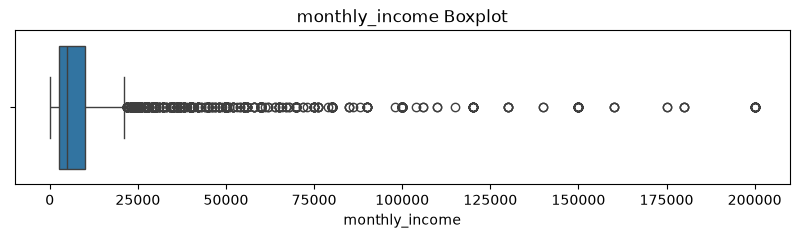

In [39]:
plt.figure(figsize=(10,2))
sns.boxplot(x=finance_df["monthly_income"])

plt.title("monthly_income Boxplot")
plt.show()

### What statistical rule can you use to define the boundary beyond which a value is an outlier?

In [40]:
Q1 = 2500
Q3 = 10000
IQR = 7500
lower_limit = Q1 - (1.5 * IQR) 
upper_limit = Q3 + (1.5 * IQR) 
print(lower_limit , upper_limit)

IQR = finance_df["monthly_income"].quantile(0.75) - finance_df["monthly_income"].quantile(0.25)
print(IQR)

-8750.0 21250.0
7500.0


In [41]:
finance_df["household_size"].describe()

count    20871.000000
mean         4.215946
std          2.512658
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         20.000000
Name: household_size, dtype: float64

### Q9: Some households report very large household sizes. Explore whether these are outliers and discuss at least two reasons they might exist in this dataset.
One reason is ploygomous households and the extended family arrangements.


In [42]:
Q1 = 2
Q3 = 6
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR) 
upper_limit = Q3 + (1.5 * IQR) 
print(f"IQR: {IQR}")
print(f"Lower limit: {lower_limit}")
print(f"Upper limit: {upper_limit}")

IQR: 4
Lower limit: -4.0
Upper limit: 12.0


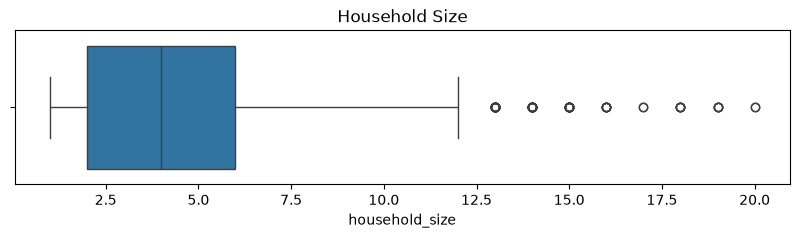

In [43]:
plt.figure(figsize=(10,2))
sns.boxplot(x=finance_df["household_size"])

plt.title("Household Size")
plt.show()

## Section 4: Data Distributions

### Q10. Investigate the shape of the monthly income distribution. What type of distribution does it resemble, and what are the implications for the statistical techniques you can use on it?

#### Plot a histogram and/or KDE curve — what do you observe about symmetry? 
The graph is a right skewed distribution

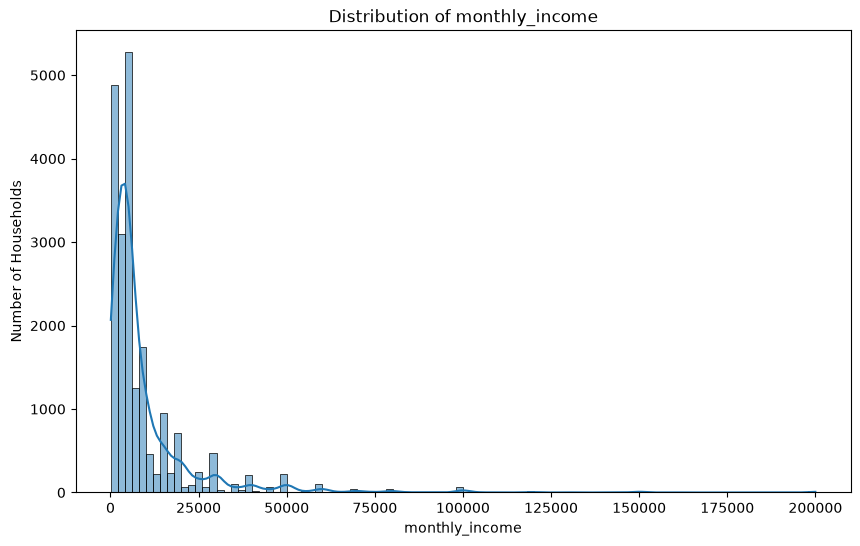

In [44]:
# Look at the shape of the income distribution
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", bins=100, kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Number of Households")
plt.show()

#### Compare the mean and median — what does a large gap suggest?
The large gap in the mean and median suggests that data distribution is right skewed due to the extreme outliers that pull the mean up.

In [45]:
mean = finance_df['monthly_income'].mean()
median = finance_df['monthly_income'].median()
print(f"Median: {median}")
print(f"Mean: {mean}")

Median: 5000.0
Mean: 9702.774280101576


#### What statistical assumption do many tests make about the distribution of data? 
- Many statistical methods start with the assumption your data follow the normal distribution.
- Homogenity of variance, groups being compared have similar amounts of spread or variation.

#### Would a log transformation help normalise this variable? Why or why not?
- Yes, this is because log transformation shrinks big numbers and stretches small numbers so that data becomes more balanced.

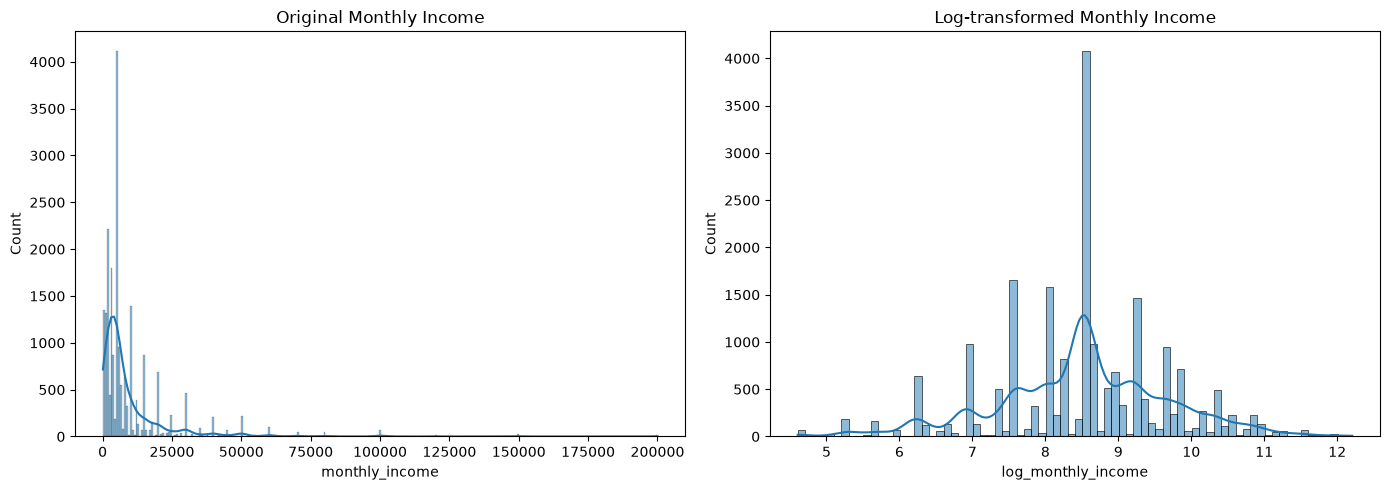

In [46]:
# trying to use log transformation to see the difference 
finance_df["log_monthly_income"] = np.log(finance_df["monthly_income"])   # log(1+x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
sns.histplot(finance_df["monthly_income"], kde=True, ax=axes[0])
axes[0].set_title("Original Monthly Income")

# Log-transformed distribution
sns.histplot(finance_df["log_monthly_income"], kde=True, ax=axes[1])
axes[1].set_title("Log-transformed Monthly Income")

plt.tight_layout()
plt.show()

In [47]:
finance_df.head()

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability,log_monthly_income
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability,10.308953
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability,9.210340
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,No,No,No,No,Improved,All correct,5,Affordability,Without Disability,8.006368
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability,9.210340
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability,9.210340


## Q11.  The number of financial products used (prodsum1) is a count variable. What kind of distribution might fit this variable, and how would you test your assumption?

_The assumption is tested by finding the mean and the variance (the variance should be higher than the mean, overdispersion)_

#### Count variables that represent the number of events are often modelled by a particular distribution which one? 
- Negative binomial distribition
- For prodsum1, the Poisson distribution would typically be the most appropriate choice for modeling count data. However, in this case, the variance is significantly larger than the mean, indicating overdispersion. This violates the Poisson assumption that the mean and variance are equal, suggesting that a Negative Binomial distribution may be a better fit.


#### Look at the mean and variance — are they roughly equal? 

In [48]:
mean = finance_df['prodsum1'].mean()
var = finance_df['prodsum1'].var()

print(f"Mean :", mean)
print(f"Variance :", var)

Mean : 3.9365626946480763
Variance : 10.419933349674846


#### Plot the distribution and compare it to what you would expect theoretically. 
- I would expect the mean and the variance to be almost the same.

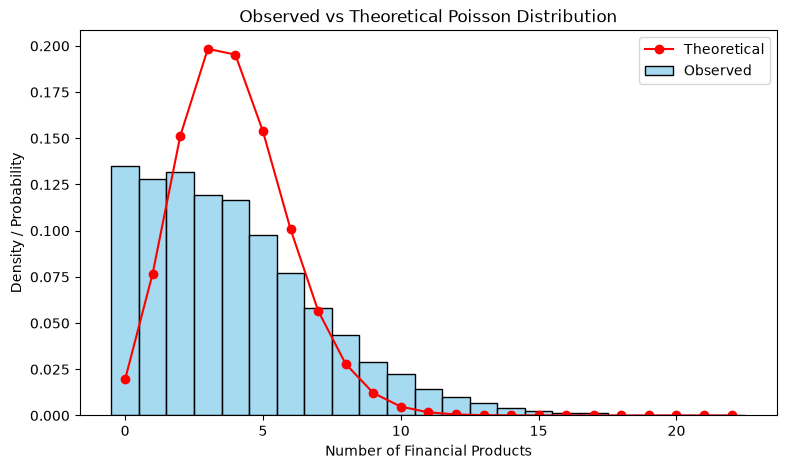

In [49]:
lam = finance_df["prodsum1"].mean()  # lambda is the mean in poisson (λ)
x = np.arange(0,23)  # This creates the possible number of products, The Poisson distribution needs to calculate the probability of observing x products, and these become the x axis

plt.figure(figsize=(9,5))

# Observed distribution
sns.histplot(finance_df["prodsum1"], stat="density", discrete=True, color="skyblue", label="Observed") 

# stat = density prevents it from using count; discrete = True tells python that this is discrete and not continuous data
# Theoretical Poisson
plt.plot(x, poisson.pmf(x, lam), marker="o", color="red", label="Theoretical") # poisson.pmf - produces the probabilities
plt.xlabel("Number of Financial Products")
plt.ylabel("Density / Probability")
plt.title("Observed vs Theoretical Poisson Distribution")
plt.legend()

plt.show()

#### What is the minimum possible value, and what does a value of zero mean here?
- The minimum possible value is zero and it means there are households that do not have access to any financial products.

In [50]:
min = finance_df['prodsum1'].min()
print(min)

0


Q12.  How would you determine whether household size follows a normal distribution? Why 

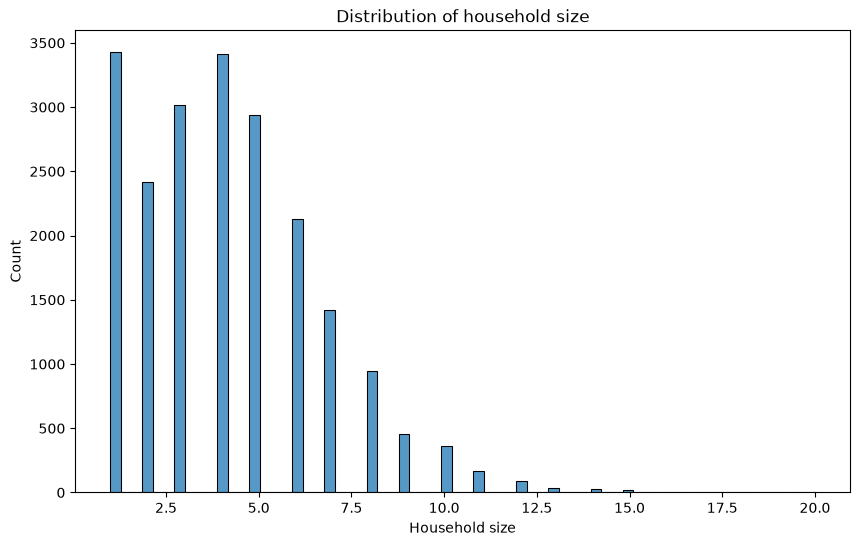

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(finance_df, x='household_size')
plt.title('Distribution of household size')
plt.xlabel('Household size')
plt.ylabel('Count')
plt.show()

__Check for normality visually using a histogram and a Q-Q plot.__

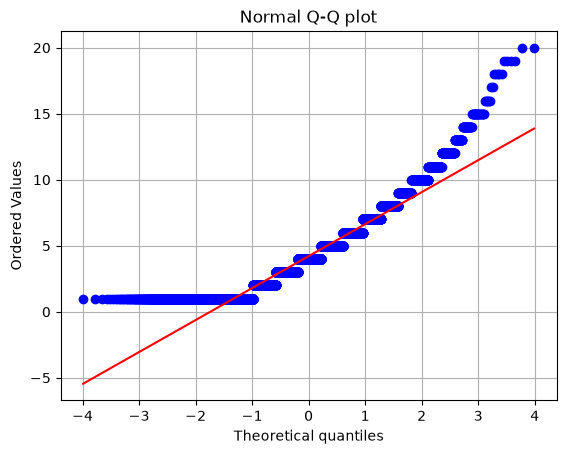

In [52]:
stats.probplot(finance_df["household_size"], dist="norm", plot=plt)
plt.title('Normal Q-Q plot')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Ordered Values')
plt.grid(True)
plt.show()

__Consider formal normality tests — what are they, and when are they reliable?__ 
- Anderson-Darling Test, 

__What is the 68–95–99.7 rule, and does the household size data conform to it?__
- Also known as emperical rule, states that 68% of data lies betweenthe 1st std devation of the mean, 95% within the 2nd std deviation and lastly 99.7% within the 3rd std deviation.
- The house hold size does not conform to the emperical rule.

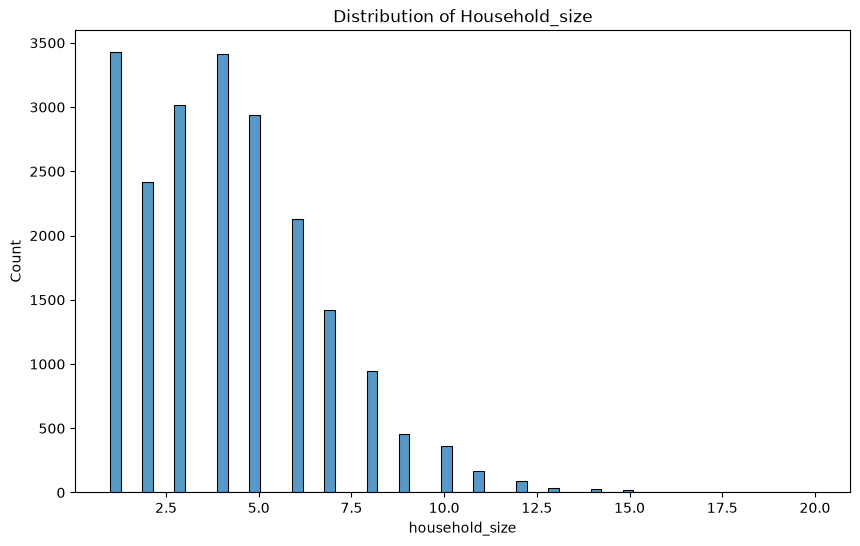

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="household_size")

plt.title("Distribution of Household_size")
plt.xlabel("household_size")
plt.show()

__If normality is violated, what are your options for analysis?__ 
- Non parametric distribution and log transformation

### Section 5: Correlation
### Q13.  Is there a relationship between monthly income and the number of financial products a household uses? Explore this relationship and interpret your finding.

__Start with a scatter plot — what pattern do you see?__
- Weak positive correlation

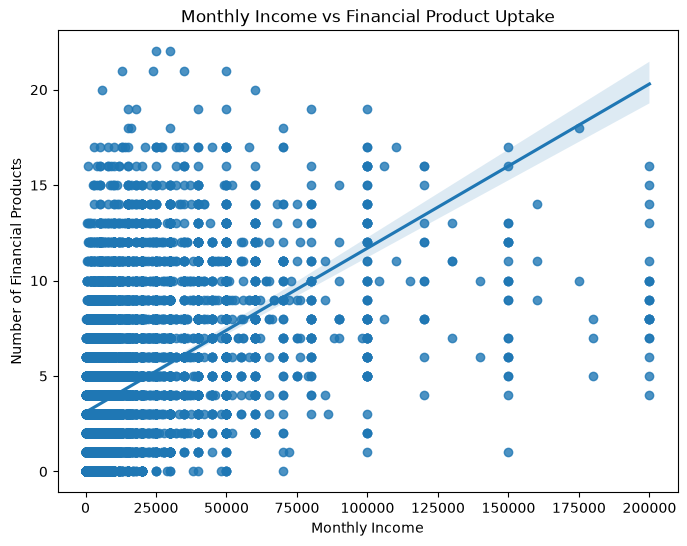

                monthly_income  prodsum1
monthly_income        1.000000  0.410813
prodsum1              0.410813  1.000000
                monthly_income  prodsum1
monthly_income        1.000000  0.168768
prodsum1              0.168768  1.000000


In [54]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=finance_df,
    x="monthly_income",
    y="prodsum1"
)

plt.title("Monthly Income vs Financial Product Uptake")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Financial Products")
plt.show()

r = finance_df[["monthly_income","prodsum1"]].corr()
print(r)
r_square = r ** 2
print(r_square)

__What correlation coefficient is appropriate for two continuous variables?__ 
- Pearson's correlation coefficient

__Interpret the sign and magnitude: what do positive, negative, and near-zero values mean?__ 
- Positive, It means both variables increase together.
- Negative, It means when one variable increses the other one decreases.
- Zero,  There is no correlation between the variables.

__Does a strong correlation mean income causes greater product use? Why or why not?__
- No it does not cause, correlation does not mean causation. Just because two variables move in the same or opposite directions, this does not mean that one variable causes the other one to change.

__Can you identify any confounding variables that might explain the relationship?__
- Education level
- Age


### Q14.  Create and interpret a correlation matrix for all numeric variables in the dataset. Which relationship are strongest and which are suprising?

__Which variables in the dataset are numeric and suitable for a correlation matrix?__

In [55]:
numeric_cols = finance_df.select_dtypes(include=['int']).columns.tolist()
print(numeric_cols)

['household_size', 'monthly_income', 'prodsum1']


__Use a heatmap to visualise the matrix — what colour scale helps interpretation?__
- Diverging scale, This is because correlation values are centered around zero and extend in two directions negative and positive the most appropriate visual encoding is usually a diverging color scale. Diverging palettes are specifically designed for variables that have a meaningful midpoint and two opposite extremes.

                household_size  monthly_income  prodsum1
household_size        1.000000       -0.116527 -0.157014
monthly_income       -0.116527        1.000000  0.433471
prodsum1             -0.157014        0.433471  1.000000


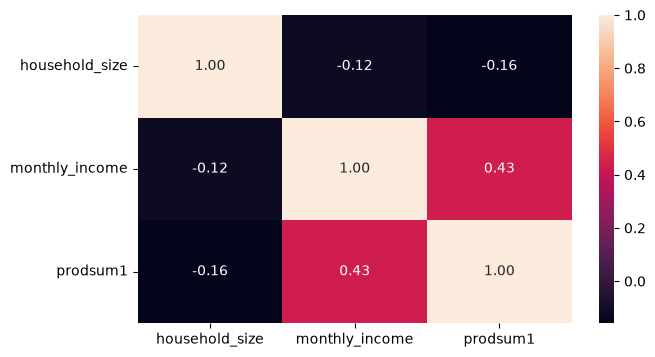

In [56]:
correlation = finance_df[numeric_cols].corr(method="spearman")
print(correlation)

plt.figure(figsize=(7, 4))
sns.heatmap(correlation, annot=True, fmt=".2f")

plt.show()

__What does a negative correlation between two variables mean practically?__
- A negative correlation means that when one variable increases tthe other one tends to decrease(they move in opposite direction)

### Q15.  A student finds a moderate positive correlation between education level and formal savings usage. They conclude that education causes people to save formally. Evaluate this conclusion.
- The is a moderate positive corelation between education and formal savings usage, but that does not mean that education level causes people to save formally since there are other variables like location type that also have a relationship with formal saving usage

__Is education level numeric or categorical? Does this affect which correlation measure to use?__
- Education level is a categorical column and the measure to use is affected since we are checking the corelation between two categorical columns, therefore, chi square test of independance is the best measure to use.

__What is the difference between correlation and causation?__
- Correlation tells relationship between two variables while causation shows that one variable cuses a change in the other.

__List at least two other variables that might explain why educated people use formal savings.__

In [57]:
#cleaning education level column
finance_df["education_level"] = finance_df["education_level"].str.strip()

finance_df["education_level"].value_counts()
finance_df["education_level"] = finance_df["education_level"].replace({'"Secondary completed "': "Secondary completed",'"Primary completed"' : "Primary completed", '"Some primary "': "Primary Incomplete", '"None "': "None",'"Some secondary"': "Secondary Incomplete", 'Completed technical training after secondary school':"Technical Training completed",'"University completed "' : "University completed", 'Some technical training after secondary school': "Technical Training Incomplete", 'Some university' : "University Incomplete"}) 

finance_df = finance_df[~finance_df["education_level"].isin(['"Refused to Answer (DO NOT READ OUT)"','"Other (Specify) "','95','"Don\'t know (DO NOT READ OUT)"'])]

In [58]:
H0 = f'The is relationship between education and formal savings usage'
H1 = f'There is a relationship between education level and formal savings usage'

alpha = 0.05
table = pd.crosstab(finance_df['education_level'], finance_df['Savings_formal'])
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(table)
print(f"Chi-square statistic: {chi2}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value}")
print(f"Expected frequencies:\n{expected.round(2)}")

if p_value <= alpha:
    print(f'Reject the null hypothesis: {H0}')
else:
    print(f'Fail to reject null hypothesis: {H0}')

Savings_formal                 Non-usage  Usage
education_level                                
None                                2519    559
Primary Incomplete                  2489   1242
Primary completed                   2228   1725
Secondary Incomplete                1840    891
Secondary completed                 1740   2373
Technical Training Incomplete        183    318
Technical Training completed         367   1054
University Incomplete                 82    264
University completed                 180    808
Chi-square statistic: 2781.387511937269
Degrees of freedom: 8
P-value: 0.0
Expected frequencies:
[[1715.61 1362.39]
 [2079.57 1651.43]
 [2203.31 1749.69]
 [1522.2  1208.8 ]
 [2292.49 1820.51]
 [ 279.25  221.75]
 [ 792.03  628.97]
 [ 192.85  153.15]
 [ 550.69  437.31]]
Reject the null hypothesis: The is relationship between education and formal savings usage


In [59]:
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / n)
print("Cramér's V:", cramers_v)

Cramér's V: 0.3651344244541303


In [60]:
finance_df.shape

(20862, 29)

In [61]:
cramer = 2781.39 / 20862
sqrt = np.sqrt(cramer)
print(sqrt)

0.36513458776779056


In [62]:
# Education level vs location type
table = pd.crosstab(finance_df["education_level"],finance_df["location_type"])
chi2, p, dof, expected = chi2_contingency(table)
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / n)

print(table)
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

# Location type and formal savings usage
table = pd.crosstab(finance_df["location_type"],finance_df["formal_service_use"])
chi2, p, dof, expected = chi2_contingency(table)
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / n)
print(table)
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

location_type                  Rural  Urban
education_level                            
None                            2461    617
Primary Incomplete              2964    767
Primary completed               2787   1166
Secondary Incomplete            1828    903
Secondary completed             2170   1943
Technical Training Incomplete    235    266
Technical Training completed     641    780
University Incomplete            108    238
University completed             350    638


Chi-square: 1843.40
p-value: 0.0000
Degrees of freedom: 8
Cramér's V: 0.2973
formal_service_use  Non-usage  Usage
location_type                       
Rural                    2115  11429
Urban                     531   6787
Chi-square: 299.05
p-value: 0.0000
Degrees of freedom: 1
Cramér's V: 0.1197


__Location type may partly account for the association between education level and formal savings use. Education level was significantly associated with location type, χ²(8) = 1843.40, p < 0.000, with a Cramér's V of 0.2973. Location type was also significantly associated with formal savings use, χ²(1) = 299.05, p < 0.001, although the strength of this association was weak (Cramér's V = 0.1197).__

In [63]:
# monthly income vs education level (Kruskal wallis test)
finance_df.groupby("education_level")["monthly_income"].agg(["count", "median"]).round(2)

,count,median
education_level,,
None,3078,5000.0
Primary Incomplete,3731,4000.0
Primary completed,3953,5000.0
Secondary Incomplete,2731,4500.0
Secondary completed,4113,6000.0
Technical Training Incomplete,501,5000.0
Technical Training completed,1421,12000.0
University Incomplete,346,8000.0
University completed,988,24500.0


In [64]:
from scipy.stats import kruskal

groups = []

for level in finance_df["education_level"].unique():
    income = finance_df[finance_df["education_level"] == level]["monthly_income"].dropna()
    
    groups.append(income)
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H: {stat:.2f}")
print(f"p-value: {p:.4f}")

Kruskal-Wallis H: 2966.99
p-value: 0.0000


__What study design would be needed to establish causation?__
- Randomized controlled trials (RCT) are prospective studies that measure the effectiveness of a new intervention or treatment. Although no study is likely on its own to prove causality, randomization reduces bias and provides a rigorous tool to examine cause-effect relationships between an intervention and outcome. This is because the act of randomization balances participant characteristics (both observed and unobserved) between the groups allowing attribution of any differences in outcome to the study intervention. This is not possible with any other study design.

## Section 6: Hypothesis Testing Framework
### Q16.  A policy researcher believes that mobile money access rates differ between rural and urban areas in Kenya. Set up a complete hypothesis test for this claim without yet running the test.

In [65]:
H0 = f'There is no difference in the mobile money access rates between the rural and urban areas.'
H1 = f'There is a difference between mobile money access rates between the rural and urban areas.'

alpha = 0.05
table = pd.crosstab(finance_df['mobile_money_access'], finance_df['location_type'])
chi2, dof, p_value, expected = chi2_contingency(table)

if p_value <= alpha:
    print(f'Reject the null hypothesis: "{H0}"')
else:
    print(f'Fail to reject the null hypothesis: "{H0}"')

print(f'Chi-square: {chi2}')
print(f'Degree of freedom: {dof}')
print(f'Expected value: \n{expected}')
print(f'P_value: {p_value}')


Fail to reject the null hypothesis: "There is no difference in the mobile money access rates between the rural and urban areas."
Chi-square: 333.1097388575661
Degree of freedom: 2.020652136260904e-74
Expected value: 
[[ 1948.95446266  1053.04553734]
 [11595.04553734  6264.95446266]]
P_value: 1


In [66]:
table

location_type,Rural,Urban
mobile_money_access,,
No,2391,611
Yes,11153,6707


In [67]:
pd.set_option('display.max_columns', None)
finance_df.head()

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability,log_monthly_income
0,Garissa,Urban,Female,26-35,5,Technical Training completed,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability,10.308953
1,Garissa,Urban,Female,Above 55,11,None,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability,9.210340
2,Busia,Urban,Female,26-35,2,Primary completed,Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability,8.006368
3,Kiambu,Urban,Male,18-25,1,Secondary Incomplete,Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability,9.210340
4,Murang'a,Urban,Female,18-25,1,Technical Training Incomplete,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability,9.210340


__What would a Type I error mean in this context? What would a Type II error mean?__
- Type I error, There is a difference between mobile money access rates between the rural and urban areas (Rejects the true null hypothesis).
- Type II error, There is no difference between mobile money access rates between the rural and urban areas (failing to reject a false null hypothesis).

![Type I & Type II Error](https://www.statisticssolutions.com/wp-content/uploads/2017/12/rachnovblog.jpg)

### Q17.  Suppose your hypothesis test returns a p-value of 0.03. Explain what this means, and describe how your conclusion would change if your significance level were 0.01 instead of 0.05

__Define p-value in plain language: what probability does it represent?__
- The probability of your observation happening by chance.

__How do you compare a p-value to a significance level to make a decision?__
- The p_value shows the likelihood of your observation happening by chance while the often denoted by the Greek letter α (alpha), represent the probability of rejecting a true null hypothesis in a statistical test. In simpler terms, they indicate the maximum acceptable risk of concluding that an effect exists when it actually doesn't.
- If the p_value is les than or equal to the significance level, the null hypothesis is rejected whereas if the p_value is greater tha the significance level, we fail to reject the null hypothesis.

__Rejecting H₀ does not prove H₁ — what does it actually mean?__
- It means your observations are unlikely to happen under the conditions of the null hypothesis

__What is the difference between statistical significance and practical importance?__
- is a measure used to determine whether the results of an experiment or study are likely to be due to something other than random chance while refers to the real-world importance or meaningfulness of the results. That is, whether the results have a tangible impact or value in a practical sense.

__If α = 0.01 and p = 0.03, what is your decision?__
- We fail to reject the null hypothesis since it is greter than the alpha.

### Q18.  You incorrectly conclude that formal savings usage differs between male and female respondents when there is actually no difference. What type of error have you made, and how could you reduce the probability?

__Name and define the two types of errors in hypothesis testing.__
- Type I Error
- Type II Error

__Which error have you committed in this scenario?__
- Type I Error

__What is the relationship between α (significance level) and the probability of this error?__
- Lower alpha reduces the probability of error

__How does sample size affect error rates?__
- Higher sample size increases the acuracy of the result

__Is there a trade-off between the two error types?__
- Reducing Type I Error could increases the probability of Type II Error

## Section 7: Parametric Statistical Tests 

### Q19.  Investigate whether the average monthly income of respondents in the dataset matches a commonly cited national benchmark. Choose and justify the appropriate test. 

__You are comparing a sample statistic to a known population value — which test handles this?__
- One sample t-test


__Check the assumptions: is the variable approximately normally distributed? (Hint: consider sample 
size.)__

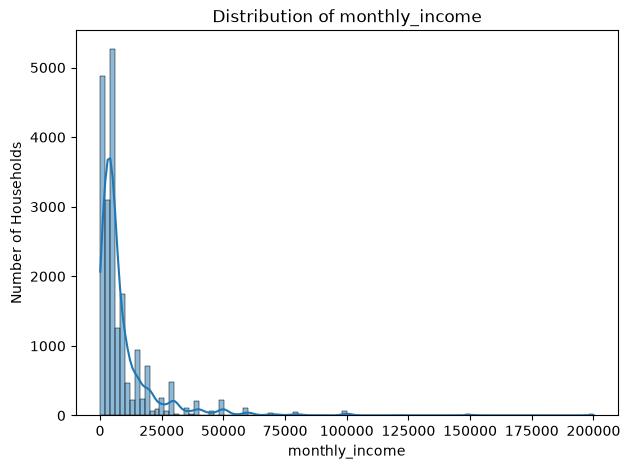

In [95]:
# Look at the shape of the income distribution
plt.figure(figsize=(7,5))
sns.histplot(data=finance_df, x="monthly_income", bins=100, kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Number of Households")
plt.show()

__State your hypotheses before running the test.__
- Statistical test appripriate  is Wilcoxon Signed-Rank Test
- H0 - There is no difference between average monthly income and the cited  national benchmark.
- H1 - There average monthly income is less than the cited national benchmark.

In [69]:
# Hypothesis testing
H0 =  "The population(benchmark) median (η) is less than or equal to sample median(η0)- η≤η0"
H1=  "The population (benchmark) median(η) is greater than the sample median(η0)- η>η0"
η = 50000
α = 0.05

income = finance_df["monthly_income"].dropna()

# Calculate differences from the benchmark
differences = income - 50000
statistic, p_value = wilcoxon(differences)
median_income = income.median()

print("Wilcoxon statistic:", statistic)
print("p-value:", p_value)
print("Median income:", median_income)

if p_value < 0.05:
    print("Reject H0: median monthly income is significantly different from KES 50,000.")
else:
    print("Fail to reject H0: insufficient evidence that median monthly income differs from KES 50,000.")


Wilcoxon statistic: 3180801.5
p-value: 0.0
Median income: 5000.0
Reject H0: median monthly income is significantly different from KES 50,000.


__What does the test statistic and p-value tell you?__  
The one-sample Wilcoxon signed-rank test produced a test statistic of W = 3.18 million and a p-value < 0.001. This provides strong evidence against the null hypothesis that the median monthly income is KES 50,000. The median monthly income was KES 5,000, which is KES 45,000 below the benchmark. Therefore, the data provide strong evidence that the median monthly income is significantly lower than KES 50,000.

__Is statistical significance the same as economic significance here?__
- __Statistical significance:__ refers to the use of a sample to carry out a statistical test meant to reveal any significant deviation from the stated null hypothesis. We then decide whether to reject or not to reject the null hypothesis.

- __Economic significance:__ entails the statistical significance and the economic effect inherent in the decision made after data analysis and testing.

## Q20.  Explore whether monthly income differs significantly between male and female respondents. Walk through the full analysis process.

- Independent ttest - Dependent variable (income) and 2 independent groups
- Assumptions: Normality - Data should be approximately normally distributed
- Homogenity of variance
- No outliers
- Independence of observations
- Sample should be randomly selected

__Are you comparing two independent groups or the same group measured twice?__
- Two independant groups

__Check normality for each group — what method would you use?__
__Assumptions of the Mann Whitney U test__
- Independence: Observations within each group, and between the groups, must be independent. This means one observation doesn't influence another.
- Ordinal Data: The dependent variable should be at least ordinal. This means the data can be ranked.
- Similar Distribution Shapes: For interpreting the test as a comparison of medians, the distributions of the two groups should have similar shapes. If the shapes are different, the test still works, but it's comparing stochastic dominance rather than medians directly.

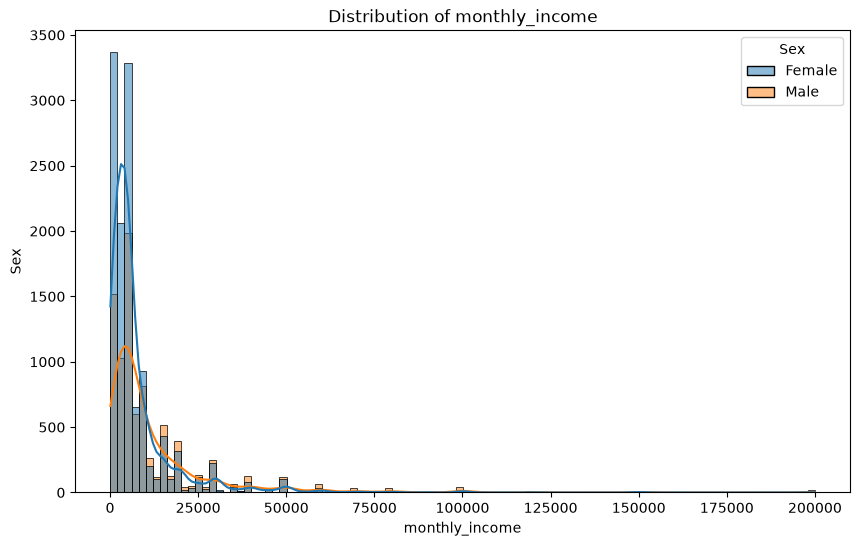

In [70]:
# Look at the shape of the income distribution
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", bins=100, hue = 'Sex', kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Sex")
plt.show()

__Check homogeneity of variance — what test or rule would you apply?__ 

In [71]:
variance_by_group = finance_df.groupby('Sex')['monthly_income'].var()
print(variance_by_group)

Sex
Female    1.530108e+08
Male      3.484533e+08
Name: monthly_income, dtype: float64


__Which version of the t-test should you use if variances are unequal?__
- Mann Whitney U test

In [72]:
# Hypothesis test
H0 = 'Monthly income is similar between Male and Female groups'
H1 = 'Monthly income is differs between Male and Female groups'

# Split into two groups
male_monthly_income = finance_df[finance_df['Sex'] == 'Male']['monthly_income']
female_monthly_income = finance_df[finance_df['Sex'] == 'Female']['monthly_income']

# Run the test
stat, p_value = mannwhitneyu(male_monthly_income, female_monthly_income, alternative='two-sided')

print(f"U statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print(f"Reject the null hypothesis: {H1}")
else:
    print(f"Fail to reject the null hypothesis: {H0}")

U statistic: 64164615.5
P-value: 4.919786032029436e-162
Reject the null hypothesis: Monthly income is differs between Male and Female groups


__Report your result with the test statistic, degrees of freedom, and p-value.__

## Q21.  Does monthly income differ significantly across the different age groups in the dataset? Design and carry out any appropiate analysis.

__You have more than two groups — which test is appropriate for comparing means?__ 
- One way ANOVA for Parametric test and Kruskal-Wallis test for Non-Parametric test

__What are the key assumptions of this test? Check them before proceeding.__
- Independance of observation
- Normally distributed data
- Homogenity of varince

__Check normality within each age group.__

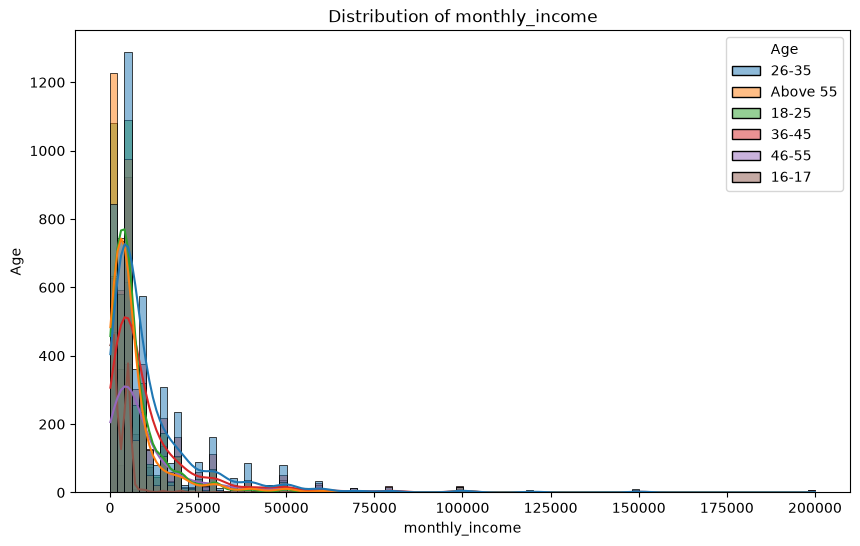

In [73]:
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", bins=100, hue = 'Age', kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Age")
plt.show()

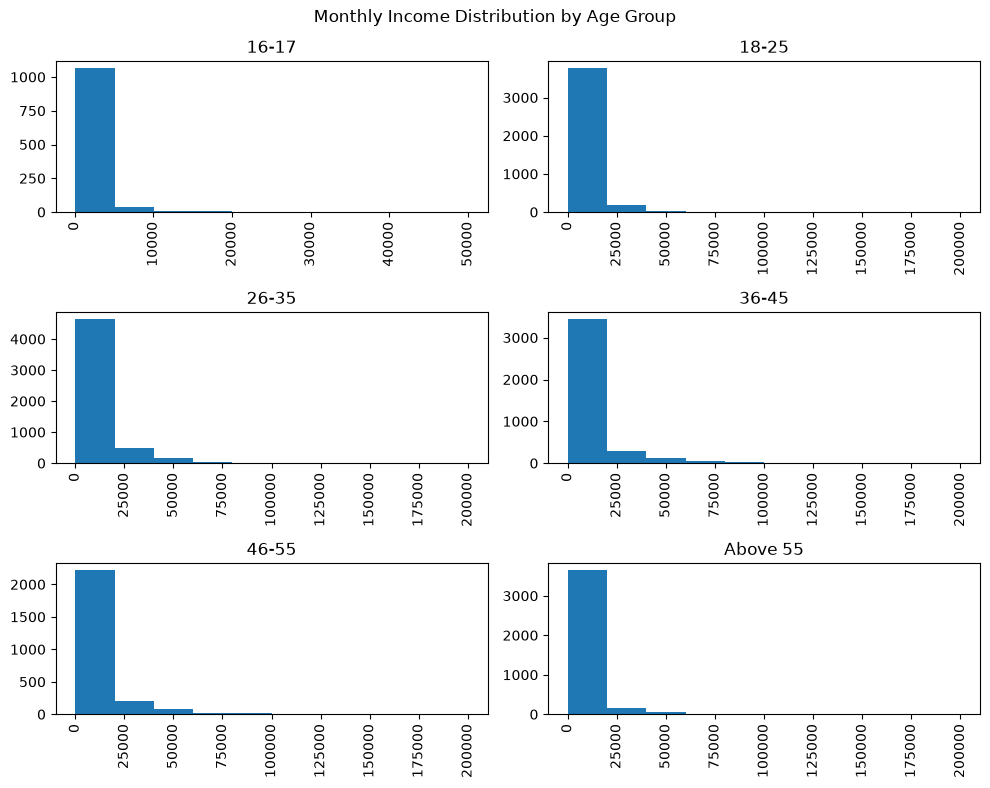

In [74]:
finance_df.hist(column="monthly_income", by="Age", figsize=(10, 8))
plt.suptitle("Monthly Income Distribution by Age Group")
plt.tight_layout()
plt.show()

__Check homogeneity of variance across groups — which test helps here?__

In [75]:
finance_df.groupby('Age')["monthly_income"].var()

Age
16-17       1.026503e+07
18-25       1.005332e+08
26-35       2.803151e+08
36-45       3.156133e+08
46-55       3.481722e+08
Above 55    1.985648e+08
Name: monthly_income, dtype: float64

__If the overall test is significant, how would you find which specific groups differ?__

In [76]:
H0 = f'There is no difference in the monthly income across the age groups'
H1 = f'There is a difference in the monthly income across the age groups'

groups = [finance_df[finance_df["Age"] == g]["monthly_income"].dropna() 
          for g in finance_df["Age"].unique()]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the Null hypothesis", H1)
else:
    print("Fail to reject the null hypothesis", H0)

Kruskal-Wallis H statistic: 1700.5954
p-value: 0.0000
Reject the Null hypothesis There is a difference in the monthly income across the age groups


In [77]:
''''H0 = f'There is no difference in the monthly income across the age groups'
H1 = f'There is a difference in the monthly income across the age groups'

groups = [finance_df[finance_df["Age"] == g]["monthly_income"].dropna() 
          for g in finance_df["Age"].unique()]

stat, p_value = f_oneway(*groups)

print(f"F-statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the Null hypothesis", H1)
else:
    print("Fail to reject the null hypothesis", H0)'''

'\'H0 = f\'There is no difference in the monthly income across the age groups\'\nH1 = f\'There is a difference in the monthly income across the age groups\'\n\ngroups = [finance_df[finance_df["Age"] == g]["monthly_income"].dropna() \n          for g in finance_df["Age"].unique()]\n\nstat, p_value = f_oneway(*groups)\n\nprint(f"F-statistic: {stat:.4f}")\nprint(f"p-value: {p_value:.4f}")\n\nif p_value < 0.05:\n    print("Reject the Null hypothesis", H1)\nelse:\n    print("Fail to reject the null hypothesis", H0)'

__Check homogeneity of variance across groups — which test helps here?__

In [78]:
H0 = f'There is no significant variance difference across age groups'
H1 = f'There is a significant difference in variances across age groups'

# Split monthly_income by AgeGroup
groups = [group['monthly_income'].values for name, group in finance_df.groupby('Age')]

# Levene's test 
stat, p_value = levene(*groups)

print(f"Levene's Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

Levene's Test Statistic: 76.9721
P-value: 0.0000
Reject the null hypothesis: There is a significant difference in variances across age groups


__If the overall test is significant, how would you find which specific groups differ?__

In [79]:
!pip install scikit-posthocs




[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import scikit_posthocs as sp

games_howell = sp.posthoc_games_howell(finance_df, val_col='monthly_income', group_col='Age')
print(games_howell)

                 26-35      Above 55     18-25     36-45     46-55  16-17
26-35     1.000000e+00  3.242184e-12  0.000000  0.999993  0.999785    0.0
Above 55  3.242184e-12  1.000000e+00  0.615354  0.000000  0.000000    0.0
18-25     0.000000e+00  6.153537e-01  1.000000  0.000000  0.000000    0.0
36-45     9.999932e-01  0.000000e+00  0.000000  1.000000  0.999989    0.0
46-55     9.997846e-01  0.000000e+00  0.000000  0.999989  1.000000    0.0
16-17     0.000000e+00  0.000000e+00  0.000000  0.000000  0.000000    1.0


In [81]:
!pip install pingouin


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import pingouin as pg

# Welch's ANOVA (robust to unequal variances)
welch_result = pg.welch_anova(dv='monthly_income', between='Age', data=finance_df)
print(welch_result)

# Games-Howell post-hoc
gh_result = pg.pairwise_gameshowell(dv='monthly_income', between='Age', data=finance_df)
print(gh_result)

  Source  ddof1        ddof2           F  p_unc       np2
0    Age      5  8849.346471  510.389716    0.0  0.029304
        A         B        mean_A        mean_B         diff          se  \
0   16-17     18-25   2807.441964   7284.901102 -4477.459137  185.300441   
1   16-17     26-35   2807.441964  11870.285501 -9062.843537  247.936592   
2   16-17     36-45   2807.441964  11820.231413 -9012.789449  298.747029   
3   16-17     46-55   2807.441964  11750.212264 -8942.770300  382.132637   
4   16-17  Above 55   2807.441964   7719.118852 -4911.676888  245.004248   
5   18-25     26-35   7284.901102  11870.285501 -4585.384399  278.349415   
6   18-25     36-45   7284.901102  11820.231413 -4535.330312  324.431241   
7   18-25     46-55   7284.901102  11750.212264 -4465.311162  402.530986   
8   18-25  Above 55   7284.901102   7719.118852  -434.217751  275.740683   
9   26-35     36-45  11870.285501  11820.231413    50.054088  363.857019   
10  26-35     46-55  11870.285501  11750.212264 

## Q22.  Examine whether the proportion of respondents with formal savings is significantly different from 50%. Choose the correct test and interpret the result.

__You are testing a single proportion against a fixed value — which test is appropriate?__
- Proportion Z-test

In [83]:
H0 = f'There is no significant difference between proprtion of residents with formal savings from 50%'
H1 = f'There is a significant difference between proprtion of residents with formal savings from 50%'

count = (finance_df['Savings_formal'] == 'Usage').sum()
nobs = finance_df['Savings_formal'].notna().sum()
value = 0.5

stat, p_val = proportions_ztest(count, nobs, value)

print(f"Proportion Z-test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Observed: {nobs}")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

Proportion Z-test Statistic: -16.6849
P-value: 0.0000
Observed: 20862
Reject the null hypothesis: There is a significant difference between proprtion of residents with formal savings from 50%


In [84]:
observed = count/nobs
observed

np.float64(0.4426229508196721)

__When is a z-test preferred over a t-test?__
- Sample size is large (commonly n > 30), Even when you don't truly know σ and have to estimate it with the sample standard deviation (s), the Central Limit Theorem means that as sample size grows, the t-distribution converges to the normal distribution. At that point, using a Z-test as an approximation gives nearly identical results to a t-test, so many practitioners default to Z for large samples out of convenience.
- Population variance (σ) is actually known, This is the textbook condition. If you have reliable, established knowledge of the true population standard deviation — not estimated from your current sample — a Z-test is the correct choice.

__What assumption does this test make about sample size?__
- The Z-test assumes a large sample size, typically greater than 30. With larger samples, the sampling distribution of the sample mean approaches a normal distribution, even if the original data are not normally distributed, according to the Central Limit Theorem.

## Section 8: Chi-Square Tests 

### Q23.  Investigate whether there is a significant association between a respondent's sex and their formal savings behaviour. Choose the appropriate test and interpret your finding. 

In [85]:
H0 = f'There is no significant relationship between respondents sex and their formal saving behaviour'
H1 = f'There is a significant relationship between respondents sex and their formal saving'

contingency_table = pd.crosstab(finance_df['Sex'], finance_df['Savings_formal'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degree of freedom: {dof}")
print(f"P-value: {p_value:.4f}")
print(contingency_table)
print(f"Expected value: \n{expected}\n")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

Chi-square statistic: 206.97
Degree of freedom: 1
P-value: 0.0000
Savings_formal  Non-usage  Usage
Sex                             
Female               7376   4946
Male                 4252   4288
Expected value: 
[[6868. 5454.]
 [4760. 3780.]]

Reject the null hypothesis: There is a significant relationship between respondents sex and their formal saving


## Q24.  Examine whether the distribution of financial status responses (Improved / Stayed the same / Worsened) is consistent with what you would expect if all outcomes were equally likely

__You are comparing an observed distribution to an expected one — which chi-square test applies?__
- Chi-square Goodness of fit

In [86]:
H0 = f'The financial status responses is equally distributed across all categories'
H1 = f'The financial status responses is not equally distributed across all categories'

# Assuming finance_df['financial_status'] has the raw responses
counts = finance_df['financial_status'].value_counts()
observed = counts.values

n = observed.sum()
expected = [n/3] * 3

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print(counts)
print(f"Chi-square: {chi2_stat:.4f}")
print(f"p_value: {p_value:.4f}")
print(f'Expected value: {expected}')
print(f'Observed values: {observed}')

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

financial_status
Worsened           10975
Stayed the same     5607
Improved            4280
Name: count, dtype: int64
Chi-square: 3614.1970
p_value: 0.0000
Expected value: [np.float64(6954.0), np.float64(6954.0), np.float64(6954.0)]
Observed values: [10975  5607  4280]
Reject the null hypothesis: The financial status responses is not equally distributed across all categories


## Q25.  Test whether mobile money access is independent of location type (urban vs rural). Discuss what the result mean for digital financial inclusion in Kenya.

In [87]:
H0 = f'Mobile money access is independant of location type'
H1 = f'Mobile money access is not independent of location type'

contingency_table = pd.crosstab(finance_df['mobile_money_access'], finance_df['location_type'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degree of freedom: {dof}")
print(f"P-value: {p_value:.4f}")
print(contingency_table)
print(f"Expected value: \n{expected}\n")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

Chi-square statistic: 333.11
Degree of freedom: 1
P-value: 0.0000
location_type        Rural  Urban
mobile_money_access              
No                    2391    611
Yes                  11153   6707
Expected value: 
[[ 1948.95446266  1053.04553734]
 [11595.04553734  6264.95446266]]

Reject the null hypothesis: Mobile money access is not independent of location type


## Section 9: Non-Parametric Tests

### Q26.  Compare the number of financial products used between urban and rural respondents, taking into account that this variable may not be normally distributed. Choose the most appropriate test.

In [88]:
H0 = f'There is no difference in the distribution of the number of financial products used between urban and rural respondents'
H1 = f'There is a difference in the distribution of the number of financial products used between urban and rural respondents.'

# Assuming df has a numeric/ordinal column and a grouping column
urban_prodsum = finance_df[finance_df['location_type'] == 'Urban']['prodsum1']
rural_prodsum = finance_df[finance_df['location_type'] == 'Rural']['prodsum1']

stat, p_value = mannwhitneyu(urban_prodsum, rural_prodsum, alternative='two-sided')

print(f"U statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

U statistic: 59120709.5000
P-value: 0.0000
Reject the null hypothesis: There is a difference in the distribution of the number of financial products used between urban and rural respondents.


In [89]:
finance_df.head()

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability,log_monthly_income
0,Garissa,Urban,Female,26-35,5,Technical Training completed,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability,10.308953
1,Garissa,Urban,Female,Above 55,11,None,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability,9.210340
2,Busia,Urban,Female,26-35,2,Primary completed,Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability,8.006368
3,Kiambu,Urban,Male,18-25,1,Secondary Incomplete,Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability,9.210340
4,Murang'a,Urban,Female,18-25,1,Technical Training Incomplete,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability,9.210340


### Q27.  Investigate whether financial product usage differs across multiple education levels. Consider what happens to your test assumption as the number of groups increases

In [90]:
H0 = f'There is a difference in financial product usage across multiple education levels'
H1 = f'There is no difference in financial product usage across multiple education levels'

groups = [group['prodsum1'].dropna() for _, group in finance_df.groupby('education_level')]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject null hypothesis:", H1)
else:
    print("Fail to reject null hypothesis: ", H0)

Kruskal-Wallis H statistic: 4688.6547
P-value: 0.0000
Reject null hypothesis: There is no difference in financial product usage across multiple education levels


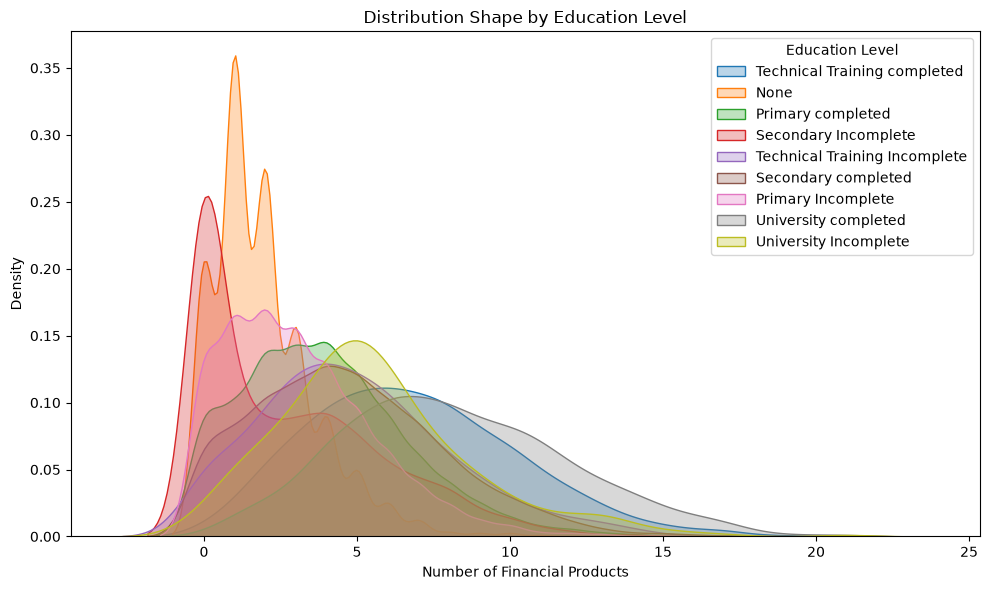

In [91]:
plt.figure(figsize=(10, 6))
for level in finance_df['education_level'].unique():
    sns.kdeplot(finance_df[finance_df['education_level'] == level]['prodsum1'], label=level, fill=True, alpha=0.3)

plt.title('Distribution Shape by Education Level')
plt.xlabel('Number of Financial Products')
plt.legend(title='Education Level')
plt.tight_layout()
plt.show()

### Q28.  A researcher wants to examine whether respondents who experienced a financial shock report different monthly incomes than those who did not, but is concerned about distributional assumptions guide them through selectin and justifying a test

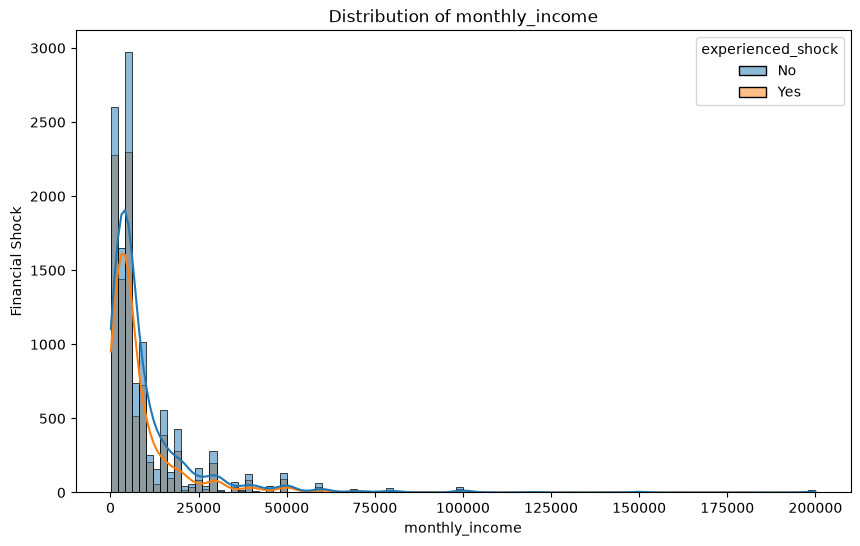

In [92]:
# Look at the shape of the income distribution
plt.figure(figsize=(10,6))
sns.histplot(data=finance_df, x="monthly_income", bins=100, hue = 'experienced_shock', kde=True)

plt.title("Distribution of monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Financial Shock")
plt.show()

In [93]:
H0 = 'There is no difference in the distribution of monthly income between respondents who experienced a financial shock and those who did not'
H1 = 'There is a difference in the distribution of monthly income between respondents who experienced a financial shock and those who did not'

# Assuming df has a numeric/ordinal column and a grouping column
yes = finance_df[finance_df['experienced_shock'] == 'Yes']['monthly_income']
no = finance_df[finance_df['experienced_shock'] == 'No']['monthly_income']

stat, p_value = mannwhitneyu(yes, no, alternative='two-sided')

print(f"U statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis:", H1)
else:
    print("Fail to reject the null hypothesis", H0)

U statistic: 50139824.0000
P-value: 0.0000
Reject the null hypothesis: There is a difference in the distribution of monthly income between respondents who experienced a financial shock and those who did not


In [94]:
finance_df.groupby('experienced_shock')['monthly_income'].median()

experienced_shock
No     5000.0
Yes    5000.0
Name: monthly_income, dtype: float64